In [16]:
%pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 5.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [1]:
from IPython.display import Audio, display, update_display, HTML

In [2]:
import kagglehub
import tensorflow as tf
import numpy as np
import librosa
import pandas as pd
import sklearn
import seaborn as sns
import umap
import pyaudio

I0000 00:00:1778829992.796871   18527 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778829994.671682   18527 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778830002.236546   18527 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
model_path = kagglehub.model_download("google/yamnet/tensorFlow2/yamnet")
model = tf.saved_model.load(model_path)

E0000 00:00:1778830035.384684   18527 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
class_map_path = f"{model_path}/assets/yamnet_class_map.csv"
class_names = pd.read_csv(class_map_path)['display_name'].tolist()

In [5]:
file_path = 'HornAudios/mixkit-car-double-horn-719.wav'
audio, _ = librosa.load(file_path, sr=16000, mono=True)

In [6]:
scores, embeddings, spectrogram = model(audio)

In [7]:
embeddings

<tf.Tensor: shape=(1, 1024), dtype=float32, numpy=
array([[0.        , 0.        , 0.        , ..., 0.00215003, 0.        ,
        0.        ]], shape=(1, 1024), dtype=float32)>

In [8]:
mean_scores = np.mean(scores, axis=0)
top_indeces = np.argsort(mean_scores)[-1:-10:-1]

In [9]:
print("Top Detections:")
for i in top_indeces:
    print(f"{class_names[i]}: {mean_scores[i]:.4f}")

Top Detections:
Vehicle horn, car horn, honking: 0.9616
Vehicle: 0.0893
Outside, urban or manmade: 0.0584
Motor vehicle (road): 0.0239
Car: 0.0154
Toot: 0.0102
Air horn, truck horn: 0.0085
Bus: 0.0044
Inside, small room: 0.0013


In [10]:
device = pyaudio.PyAudio()

ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.rear
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.center_lfe
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.side
ALSA lib pcm_route.c:878:(find_matching_chmap) Found no matching channel map
ALSA lib pcm_route.c:878:(find_matching_chmap) Found no matching channel map
ALSA lib pcm_route.c:878:(find_matching_chmap) Found no matching channel map
ALSA lib pcm_route.c:878:(find_matching_chmap) Found no matching channel map
Cannot connect to server socket err = No such file or directory
Cannot connect to server request channel
jack server is not running or cannot be started
JackShmReadWritePtr::~JackShmReadWritePtr - Init not done for -1, skipping unlock
JackShmReadWritePtr::~JackShmReadWritePtr - Init not done for -1, skipping unlock


In [11]:
stream = device.open(format=pyaudio.paFloat32,
                channels=1,
                rate=16000,
                input=True,
                frames_per_buffer=16000)

In [12]:
data = stream.read(int(16000 * 0.96), exception_on_overflow=False)

In [13]:
audd = np.frombuffer(data, dtype=np.float32)

In [14]:
Audio(data=audd, rate=16000)

In [15]:
k = display('fahhh', display_id=True)

'fahhh'

In [16]:
should_stop = True

In [17]:
hndl = display('First 10 Predicted Values: ', display_id=True)
while should_stop:
    data = stream.read(int(16000 * 1.5), exception_on_overflow=False)
    audd = np.frombuffer(data, dtype=np.float32)
    
    scores, embeddings, spectogram = model(audd)
    
    mean_scores = np.mean(scores, axis=0)
    top_indices = np.argsort(mean_scores)[-1:-10:-1]

    out = '<br>'.join([class_names[i] for i in top_indices])
    
    hndl.update(HTML(out))

KeyboardInterrupt: 

## Collect Data

In [18]:
import scipy
import time

In [22]:
collected = []
labels = []

audio_collect = np.array([])

reducer = sklearn.decomposition.IncrementalPCA(n_components=2)

k = 0

filterer = scipy.signal.butter(5, [350, 1800], btype='bandpass', analog=False, output='sos', fs=16000)

hndl = display('First 10 Predicted Values: ', display_id=True)
for i in range(30):
    data = stream.read(int(16000 * 1), exception_on_overflow=False)
    audd = np.frombuffer(data, dtype=np.float32)
    #audd = audio_collect[i * 16000 : (i + 1) * 16000]
    audd = scipy.signal.sosfiltfilt(filterer, audd)
    
    audio_collect = np.concat((audio_collect, audd))
    time.sleep(1)
    
    scores, embeddings, spectogram = model(audd)

    embed = np.mean(embeddings, axis=0)
    mean_scores = np.mean(scores, axis=0)
    top_indices = np.argsort(mean_scores)[-1:-10:-1]

    this_label=[]
    settle_score = 0
    for i in top_indices:
        if settle_score > 0.95:
            break
        settle_score += mean_scores[i]
        this_label.append(class_names[i])
    
    labels.append('; '.join(this_label))
    collected.append(embed)

    k = k + 1
    if k == reducer.n_components:
        reducer.partial_fit(collected[-reducer.n_components:])
        k = 0

    out = '<br>'.join(this_label) #[class_names[i] for i in top_indices])
    
    hndl.update(HTML(out))

collected = np.array(collected)
labels = np.array(labels)

print(len(collected))

Audio(data=audio_collect, rate=16000)

30


In [74]:
collected.shape

(30, 1024)

In [75]:
labels

array(['Speech; Music; Radio; Inside, small room; Alarm; Synthetic singing; Singing; Siren; Christmas music',
       'Speech; Radio; Telephone; Inside, small room; Alarm; Narration, monologue; Inside, large room or hall; Speech synthesizer; Conversation',
       'Speech; Radio; Telephone; Narration, monologue; Alarm; Inside, small room; Speech synthesizer; Music; Television',
       'Dog; Domestic animals, pets', 'Telephone; Alarm; Ringtone',
       'Vehicle horn, car horn, honking',
       'Speech; Inside, small room; Radio; Whimper; Whoop; Music; Crying, sobbing; Domestic animals, pets; Telephone',
       'Inside, small room; Music; Crying, sobbing; Alarm; Whimper; Telephone; Speech; Bell; Ringtone',
       'Music; Alarm; Harmonica; Musical instrument; Siren; Crying, sobbing; Vehicle horn, car horn, honking; Wind instrument, woodwind instrument; Inside, small room',
       'Speech; Dog; Domestic animals, pets; Bow-wow; Yip; Inside, small room; Animal; Whimper (dog); Howl',
       'Ch

In [76]:
reduced = reducer.transform(collected)
reduced

array([[-3.20326902,  0.33264339],
       [-3.08178393, -0.92025315],
       [-2.3817423 , -0.29168915],
       [-3.52814051,  4.36692398],
       [-0.37492588, -0.05653755],
       [ 7.20244105, -0.1583996 ],
       [-3.38552381,  0.46142725],
       [-1.08352632, -0.12663354],
       [ 0.2964419 , -0.4253624 ],
       [-3.00557521,  1.10553242],
       [-3.16219707, -2.05439355],
       [-3.43588218, -2.05858233],
       [-3.06728832, -2.25179722],
       [-0.12111429, -2.95234277],
       [-0.83532132, -0.73444795],
       [ 2.01348147,  0.18885697],
       [-3.0846741 , -0.62921367],
       [ 3.60610902, -0.34140117],
       [ 2.16315747, -1.73294008],
       [ 0.50709738, -0.93259957],
       [ 1.6905193 ,  0.37011985],
       [ 0.46316002,  3.9053483 ],
       [ 6.74118287,  0.1551046 ],
       [ 3.61707561,  0.33942761],
       [ 1.89315745,  0.35438215],
       [ 1.77713442, -0.08009804],
       [-0.63062757,  4.0815675 ],
       [ 1.76144816, -1.09197215],
       [ 0.52076968,

## Birch to create clusters

In [77]:
cluster = sklearn.cluster.Birch(n_clusters=None, threshold=0.7)
cluster.fit(reduced)

,"threshold threshold: float, default=0.5The radius of the subcluster obtained by merging a new sample and theclosest subcluster should be lesser than the threshold. Otherwise a newsubcluster is started. Setting this value to be very low promotessplitting and vice-versa.",0.7
,"branching_factor branching_factor: int, default=50Maximum number of CF subclusters in each node. If a new samples enterssuch that the number of subclusters exceed the branching_factor thenthat node is split into two nodes with the subclusters redistributedin each. The parent subcluster of that node is removed and two newsubclusters are added as parents of the 2 split nodes.",50
,"n_clusters n_clusters: int, instance of sklearn.cluster model or None, default=3Number of clusters after the final clustering step, which treats thesubclusters from the leaves as new samples.- `None` : the final clustering step is not performed and the subclusters are returned as they are.- :mod:`sklearn.cluster` Estimator : If a model is provided, the model is fit treating the subclusters as new samples and the initial data is mapped to the label of the closest subcluster.- `int` : the model fit is :class:`AgglomerativeClustering` with `n_clusters` set to be equal to the int.",None
,"compute_labels compute_labels: bool, default=TrueWhether or not to compute labels for each fit.",True


In [78]:
cluster.predict(reduced)

array([ 0,  0,  0,  1,  2,  3,  4,  2, 10,  4,  5,  5,  5,  6,  2,  7,  0,
        8,  9, 10,  7, 11,  3,  8,  7,  7, 11,  9, 10, 12])

In [79]:
cluster.subcluster_centers_

array([[-3.02739863e+00, -2.09417064e-01],
       [-3.52814051e+00,  4.36692398e+00],
       [-4.99332903e-01, -3.35745357e-01],
       [ 6.97181196e+00, -1.64750330e-03],
       [-3.00557521e+00,  1.10553242e+00],
       [-3.22178919e+00, -2.12159104e+00],
       [-1.21114292e-01, -2.95234277e+00],
       [ 1.84357316e+00,  2.08315233e-01],
       [ 3.61159232e+00, -9.86779178e-04],
       [ 1.96230282e+00, -1.41245611e+00],
       [ 5.13933529e-01, -4.82443670e-01],
       [-8.37337797e-02,  3.99345790e+00],
       [ 1.28416027e-01,  1.20961764e+00]])

In [62]:
df = pd.DataFrame(reduced.T.T, columns=['X','Y'])
df['catagory'] = cluster.predict(reduced)
df['label'] = labels
df

,X,Y,catagory,label
0,-3.998035,-1.634797,0,"Speech; Inside, small room; Synthetic singing;..."
1,-3.845639,-0.455419,0,"Speech; Inside, small room; Radio; Telephone; ..."
2,-3.294558,-1.210001,0,"Speech; Radio; Narration, monologue; Televisio..."
3,-4.369610,-2.536969,1,"Dog; Domestic animals, pets"
4,-0.142773,-0.490513,2,"Telephone; Vehicle horn, car horn, honking; Ri..."
5,5.763035,-0.948265,3,"Vehicle horn, car horn, honking"
6,-3.968862,-1.407920,0,"Speech; Music; Inside, small room; Inside, lar..."
7,-0.261087,0.422299,2,"Vehicle horn, car horn, honking; Inside, small..."
8,2.073132,0.152486,4,"Buzzer; Vehicle horn, car horn, honking; Music..."
9,-3.821776,-0.838756,0,"Speech; Dog; Domestic animals, pets; Inside, s..."


<Axes: xlabel='X', ylabel='Y'>

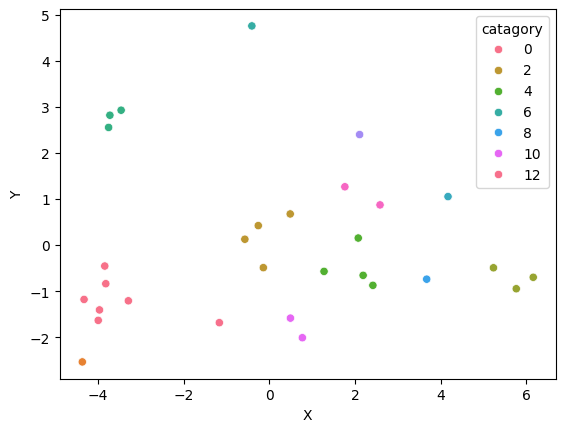

In [63]:
sns.scatterplot(df, x='X', y='Y', hue='catagory', legend='brief', palette='husl')

## Adding Transformers to the mix

In [64]:
import ollama
from ollama import chat
from ollama import ChatResponse

In [65]:
catagories_unprocessed_labels = df.groupby('catagory')['label'].agg('; '.join)

In [66]:
processed_labels = []

def get_label_prediction(k):
    gen = ollama.generate(model='smollm2',
                    prompt=f'''Output the word or phrase which is most correlated with the following senquence of word: {k}''',
                    options={
                      'temperature': 0, # Makes it deterministic
                    })
    return gen['response']

In [67]:
processed_labels = catagories_unprocessed_labels.apply(get_label_prediction)
procd = processed_labels.str.extract(r'\"(.*)\"')

ResponseError: model requires more system memory (2.4 GiB) than is available (1.4 GiB) (status code: 500)

In [41]:
df['processed_labels'] = df['catagory'].apply(lambda a: procd.loc[a]).str.extract(r'.?.?.?.?.?.?.?.?.?.?.?.?.?.?.?.?.?.?.?.')

AttributeError: 'DataFrame' object has no attribute 'str'

In [42]:
procd

,0
catagory,
0,child speech
1,Jingle bell
2,child
3,sound effect
4,"Ping"". This term appears in multiple contexts ..."
5,Inside
6,speech


In [44]:
df['processed_labels'] = procd

In [45]:
df['processed_labels'] = df['processed_labels'].str.extract(r'(\w+)')

<Axes: xlabel='X', ylabel='Y'>

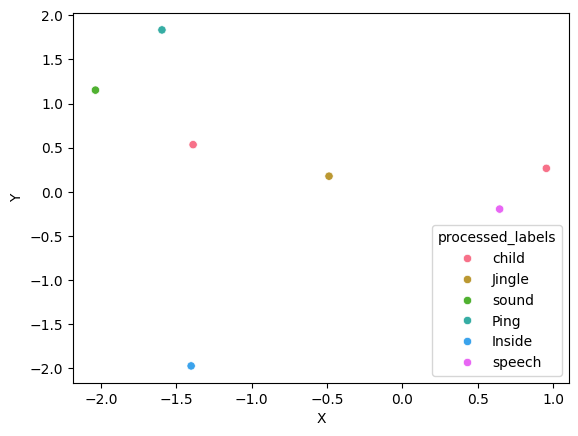

In [46]:
sns.scatterplot(df, x='X', y='Y', hue='processed_labels', legend='brief', palette='husl')